In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates  
# import plotly.graph_objects as go
# from Custom_tools.plotting_utils import plot_ohlc_with_sr

In [74]:
filename = "ADANIPORTS"
resolution = 5

In [75]:
df = pd.read_csv(f"./data/{5}_min_data/{filename}.csv")
df.index = pd.to_datetime(df.index)
# df = df.set_index('Datetime')
df.index = pd.to_datetime(df.index)
df.head()


,datetime,open,high,low,close,volume
1970-01-01 00:00:00.000000000,2024-01-01 09:20:00+05:30,1026.55,1028.90,1025.00,1027.20,67796
1970-01-01 00:00:00.000000001,2024-01-01 09:25:00+05:30,1027.20,1028.85,1025.30,1027.75,43644
1970-01-01 00:00:00.000000002,2024-01-01 09:30:00+05:30,1027.40,1028.60,1025.25,1026.15,45542
1970-01-01 00:00:00.000000003,2024-01-01 09:35:00+05:30,1026.00,1027.05,1025.00,1026.70,23822
1970-01-01 00:00:00.000000004,2024-01-01 09:40:00+05:30,1026.70,1027.00,1025.10,1025.50,12497


In [76]:
df["resistance"] = df["close"].shift().rolling(10).max()
df["support"]    = df["close"].shift().rolling(10).min()

df= df.dropna(how="any")


    ATR implementation for stop loss

In [77]:
# Calculate True Range (Wilder's definition)
df['prev_close'] = df['close'].shift(1)
df['tr'] = df[['high', 'low', 'prev_close']].apply(
    lambda x: max(x['high'] - x['low'], 
                  abs(x['high'] - x['prev_close']), 
                  abs(x['low'] - x['prev_close'])), axis=1
)
df['atr'] = df['tr'].shift().rolling(14).mean()

#### Indicators as filter

In [78]:
# Calculate RSI (14-period standard)
def calculate_rsi(data, period=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

# Add RSI
df['rsi'] = calculate_rsi(df['close'], period=14).shift()  # shift to avoid lookahead


#### Creating Strategy

    Adding a trend filter.

In [79]:
# Add simple trend filter
df['sma_50'] = df['close'].shift().rolling(50).mean()
df['sma_200'] = df['close'].shift().rolling(200).mean()
df["sma_20"] = df["close"].shift().rolling(20).mean() 

# Uptrend: price > SMA50 > SMA200
df['uptrend'] = (
                 (df['sma_50'] > df['sma_200']) &
                 (df["close"]>df["sma_20"])
                 ).astype(int)

df["downtrend"] = ( 
                #  (df['sma_50']< df['sma_200']) &
                 (df["close"]<df["sma_20"])
                 ).astype(int)


    Calculating Entry Signal 

In [80]:
df['entry_signal'] = (
    (df['low'] <= df['support']) &
    (df['rsi'] > 35) &
    (df['rsi'] < 55) &
    (df['uptrend'] == 1)
).astype(int)


    Calculating Entry Price

In [81]:
df["entry_price"] = np.where(df["entry_signal"]==1, df["support"], np.nan)

    Calculating Exit conditions

In [82]:
df["target_price"] = np.where(df["entry_signal"]==1, df["resistance"], np.nan )

df["stop_loss_price"] = np.where(df["entry_signal"]==1, df["entry_price"]-(1 * df["atr"]), np.nan)

#### Creating positions

In [83]:
df.head()

,datetime,open,high,low,close,volume,resistance,support,prev_close,tr,...,rsi,sma_50,sma_200,sma_20,uptrend,downtrend,entry_signal,entry_price,target_price,stop_loss_price
1970-01-01 00:00:00.000000010,2024-01-01 10:10:00+05:30,1024.20,1025.00,1024.05,1024.20,10278,1027.75,1024.05,NaN,0.95,...,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN
1970-01-01 00:00:00.000000011,2024-01-01 10:15:00+05:30,1024.20,1024.65,1023.10,1023.60,13020,1027.75,1024.05,1024.20,1.55,...,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN
1970-01-01 00:00:00.000000012,2024-01-01 10:20:00+05:30,1023.60,1024.95,1023.50,1023.75,14442,1026.70,1023.60,1023.60,1.45,...,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN
1970-01-01 00:00:00.000000013,2024-01-01 10:25:00+05:30,1023.75,1025.00,1023.10,1024.85,11583,1026.70,1023.60,1023.75,1.90,...,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN
1970-01-01 00:00:00.000000014,2024-01-01 10:30:00+05:30,1024.35,1025.80,1024.35,1025.00,8428,1025.50,1023.60,1024.85,1.45,...,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN


    Initializing variables

In [84]:
#INitializing trade pnl logic
df["trade_pnl"] = 0.0
df["exit_reason"] = ''
df["in_position"] = 0
trade_pnls = []
starting_capital = df.iloc[0]['close']
# starting_capital = 10000


entry_price = np.nan
stop_price = np.nan
target_price = np.nan
in_trade = False
TRANSACTION_COST = 0.0002

#For machine Learning
entry_index = None
df["ml_target"] =  np.nan
df["holding_period"] = np.nan

In [85]:
for i in range(len(df)):
    idx = df.index[i]

    #Mark if we are in position in this bar

    df.loc[idx, "in_position"] = 1 if  in_trade else 0


    #Exit logic first

    if in_trade:
        current_low = df.loc[idx, "low"]
        current_high = df.loc[idx, "high"]

        #Exit conditions
        if current_low<= stop_price:
            exit_price = stop_price
            exit_reason = "STOP" 
        elif current_high >= target_price:
            exit_price = target_price
            exit_reason = "TARGET"
        else:
            exit_price = None
        #Calculating PNL
        if exit_price is not None:
            pnl_per_share_gross = exit_price - entry_price
            
            #Calculating transaction cost
            cost_entry_per_share = entry_price * TRANSACTION_COST
            cost_exit_per_share = exit_price * TRANSACTION_COST
            total_cost_per_share = cost_entry_per_share + cost_exit_per_share

            pnl_per_share_net = pnl_per_share_gross - total_cost_per_share

            #Calculate position size
            # position_value = starting_capital
            # shares = position_value/entry_price
            shares = 1

            #Total pnl for the position
            pnl_total_gross = pnl_per_share_gross * shares
            total_cost_total = total_cost_per_share * shares
            pnl_total_net = pnl_per_share_net * shares

            trade_pnls.append(pnl_total_net)

            # Assign to dataframe at exit bar

            df.loc[idx, 'trade_pnl'] =  pnl_total_net
            df.loc[idx, 'exit_reason'] = exit_reason
            # Use percentage return (comparable across stocks):
            df.loc[entry_index, 'ml_target'] = (pnl_per_share_net / entry_price) * 100
            df.loc[entry_index, "holding_period"] = i - df.index.get_loc(entry_index)


            #Reset state

            in_trade = False
            entry_price = np.nan
            stop_price = np.nan
            target_price = np.nan
    
    #Entry logic
    elif df.loc[idx, "entry_signal"] == 1:
        in_trade = True
        entry_price = df.loc[idx, "entry_price"]
        stop_price = df.loc[idx, "stop_loss_price"]
        target_price = df.loc[idx, "target_price"]

        entry_index = idx



In [86]:
np.sum(trade_pnls)

np.float64(459.8073299999994)

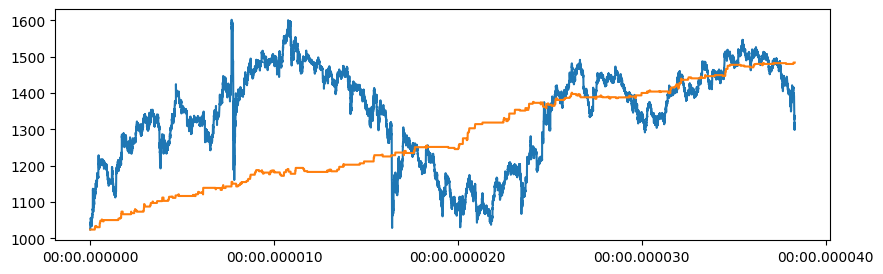

In [87]:
df["cumulative_pnl"] = df["trade_pnl"].cumsum()
df["equity_curve"] = starting_capital + df["cumulative_pnl"]

fig, ax = plt.subplots(figsize=(10,3))
ax.plot(df["close"])
ax.plot(df["equity_curve"])

#### Trade metrics

In [88]:
import numpy as np

# Daily equity-based Sharpe (correct for intraday)
daily_equity = df.groupby(df.index.date)['equity_curve'].last()
daily_returns = daily_equity.pct_change().dropna()
sharpe = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252)

# Other key metrics
returns = df[df['trade_pnl'] != 0]['trade_pnl'] / starting_capital
total_return = (df['equity_curve'].iloc[-1] - starting_capital) / starting_capital * 100
num_trades = len(returns)
win_rate = (returns > 0).sum() / num_trades * 100 if num_trades > 0 else 0

# Max Drawdown
running_max = df['equity_curve'].cummax()
drawdown = (df['equity_curve'] - running_max) / running_max * 100
max_drawdown = drawdown.min()

# Profit Factor
gross_profit = returns[returns > 0].sum() * starting_capital
gross_loss = abs(returns[returns < 0].sum() * starting_capital)
profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.inf

# Print results
print(f"Total Return: {total_return:.2f}%")
print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Max Drawdown: {max_drawdown:.2f}%")
print(f"Win Rate: {win_rate:.2f}%")
print(f"Total Trades: {num_trades}")
print(f"Profit Factor: {profit_factor:.2f}")

Total Return: 44.89%
Sharpe Ratio: nan
Max Drawdown: -1.33%
Win Rate: 64.73%
Total Trades: 275
Profit Factor: 2.25


In [89]:
df.columns

Index(['datetime', 'open', 'high', 'low', 'close', 'volume', 'resistance',
       'support', 'prev_close', 'tr', 'atr', 'rsi', 'sma_50', 'sma_200',
       'sma_20', 'uptrend', 'downtrend', 'entry_signal', 'entry_price',
       'target_price', 'stop_loss_price', 'trade_pnl', 'exit_reason',
       'in_position', 'ml_target', 'holding_period', 'cumulative_pnl',
       'equity_curve'],
      dtype='str')

In [90]:
df

,datetime,open,high,low,close,volume,resistance,support,prev_close,tr,...,entry_price,target_price,stop_loss_price,trade_pnl,exit_reason,in_position,ml_target,holding_period,cumulative_pnl,equity_curve
1970-01-01 00:00:00.000000010,2024-01-01 10:10:00+05:30,1024.20,1025.00,1024.05,1024.20,10278,1027.75,1024.05,NaN,0.95,...,NaN,NaN,NaN,0.0,,0,NaN,NaN,0.00000,1024.20000
1970-01-01 00:00:00.000000011,2024-01-01 10:15:00+05:30,1024.20,1024.65,1023.10,1023.60,13020,1027.75,1024.05,1024.20,1.55,...,NaN,NaN,NaN,0.0,,0,NaN,NaN,0.00000,1024.20000
1970-01-01 00:00:00.000000012,2024-01-01 10:20:00+05:30,1023.60,1024.95,1023.50,1023.75,14442,1026.70,1023.60,1023.60,1.45,...,NaN,NaN,NaN,0.0,,0,NaN,NaN,0.00000,1024.20000
1970-01-01 00:00:00.000000013,2024-01-01 10:25:00+05:30,1023.75,1025.00,1023.10,1024.85,11583,1026.70,1023.60,1023.75,1.90,...,NaN,NaN,NaN,0.0,,0,NaN,NaN,0.00000,1024.20000
1970-01-01 00:00:00.000000014,2024-01-01 10:30:00+05:30,1024.35,1025.80,1024.35,1025.00,8428,1025.50,1023.60,1024.85,1.45,...,NaN,NaN,NaN,0.0,,0,NaN,NaN,0.00000,1024.20000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1970-01-01 00:00:00.000038312,2026-01-23 15:10:00+05:30,1302.80,1308.20,1300.20,1307.60,188944,1318.60,1298.50,1303.50,8.00,...,NaN,NaN,NaN,0.0,,0,NaN,NaN,459.80733,1484.00733
1970-01-01 00:00:00.000038313,2026-01-23 15:15:00+05:30,1308.10,1311.10,1304.70,1309.50,174818,1318.60,1298.50,1307.60,6.40,...,NaN,NaN,NaN,0.0,,0,NaN,NaN,459.80733,1484.00733
1970-01-01 00:00:00.000038314,2026-01-23 15:20:00+05:30,1308.70,1314.00,1308.00,1310.50,185035,1318.60,1298.50,1309.50,6.00,...,NaN,NaN,NaN,0.0,,0,NaN,NaN,459.80733,1484.00733
1970-01-01 00:00:00.000038315,2026-01-23 15:25:00+05:30,1310.60,1313.00,1305.30,1310.70,157324,1318.60,1298.50,1310.50,7.70,...,NaN,NaN,NaN,0.0,,0,NaN,NaN,459.80733,1484.00733


In [91]:
df['ml_target'].values

array([nan, nan, nan, ..., nan, nan, nan], shape=(38307,))

In [92]:
df['ml_target'].notna().sum()

np.int64(275)

In [93]:
df['ml_target'].isna().sum()

np.int64(38032)

In [94]:
# Add this right after your loop
print(f"\nTotal trades executed: {len(trade_pnls)}")
print(f"ML targets stored: {df['ml_target'].notna().sum()}")
print(f"Entry signals: {(df['entry_signal'] == 1).sum()}")


Total trades executed: 275
ML targets stored: 275
Entry signals: 350


#### Adding shorting opportunities

In [95]:
df['entry_signal_short'] = (
    (df['high'] >= df['resistance']) &
    (df['rsi'] > 50) &  # Price showing strength/overbought
    (df['rsi'] < 70)   # But not extremely overbought
    & (df['downtrend'] == 1)
).astype(int)

In [96]:
# Entry at close when price touches resistance
df["entry_price_short"] = np.where(df["entry_signal_short"]==1, 
                                    df["resistance"], 
                                    np.nan)

In [97]:

df["target_price_short"] = np.where(df["entry_signal_short"]==1, 
                                    df["support"],  # or df["close"] - (2 * df["atr"])
                                    np.nan)

# Stop ABOVE entry (correct - you have this right!)
df["stop_loss_price_short"] = np.where(df["entry_signal_short"]==1, 
                                       df["entry_price_short"] + (1 * df["atr"]), 
                                       np.nan)

In [98]:
# Initializing trade pnl logic for SHORTS
df["trade_pnl_short"] = 0.0
df["exit_reason_short"] = ''
df["in_position_short"] = 0
trade_pnls_short = []
starting_capital_short = df.iloc[0]['close']
# starting_capital_short = 10000

entry_price_short = np.nan
stop_price_short = np.nan
target_price_short = np.nan
in_trade_short = False
TRANSACTION_COST_SHORT = 0.0002  # Consider if shorts have higher costs

# For machine learning
entry_index_short = None
df["ml_target_short"] = np.nan
df["holding_period_short"] = np.nan

In [99]:
for i in range(len(df)):
    idx = df.index[i]

    # Mark if we are in position in this bar
    df.loc[idx, "in_position_short"] = 1 if in_trade_short else 0

    # Exit logic first
    if in_trade_short:
        current_low = df.loc[idx, "low"]
        current_high = df.loc[idx, "high"]

        # Exit conditions (INVERTED for shorts)
        if current_high >= stop_price_short:  # Stop hit when price goes UP
            exit_price = stop_price_short
            exit_reason = "STOP" 
        elif current_low <= target_price_short:  # Target hit when price goes DOWN
            exit_price = target_price_short
            exit_reason = "TARGET"
        else:
            exit_price = None
            
        # Calculating PNL
        if exit_price is not None:
            # INVERTED: profit when exit < entry for shorts
            pnl_per_share_gross = entry_price_short - exit_price  
            
            # Calculating transaction cost
            cost_entry_per_share = entry_price_short * TRANSACTION_COST_SHORT
            cost_exit_per_share = exit_price * TRANSACTION_COST_SHORT
            total_cost_per_share = cost_entry_per_share + cost_exit_per_share

            pnl_per_share_net = pnl_per_share_gross - total_cost_per_share

            # Calculate position size
            # position_value = starting_capital_short
            # shares = position_value / entry_price_short
            shares = 1

            # Total pnl for the position
            pnl_total_gross = pnl_per_share_gross * shares
            total_cost_total = total_cost_per_share * shares
            pnl_total_net = pnl_per_share_net * shares

            trade_pnls_short.append(pnl_total_net)

            # Assign to dataframe at exit bar
            df.loc[idx, 'trade_pnl_short'] = pnl_total_net
            df.loc[idx, 'exit_reason_short'] = exit_reason
            
            # Use percentage return (comparable across stocks):
            df.loc[entry_index_short, 'ml_target_short'] = (pnl_per_share_net / entry_price_short) * 100
            df.loc[entry_index_short, "holding_period_short"] = i - df.index.get_loc(entry_index_short)

            # Reset state
            in_trade_short = False
            entry_price_short = np.nan
            stop_price_short = np.nan
            target_price_short = np.nan
    
    # Entry logic
    elif (df.loc[idx, "entry_signal_short"] == 1) and (not in_trade_short):

        in_trade_short = True
        entry_price_short = df.loc[idx, "entry_price_short"]
        stop_price_short = df.loc[idx, "stop_loss_price_short"]
        target_price_short = df.loc[idx, "target_price_short"]
        
        entry_index_short = idx

In [100]:
np.sum(trade_pnls_short)

np.float64(754.6007714285713)

In [101]:
df["trade_pnl_total"] = df["trade_pnl"] + df["trade_pnl_short"]


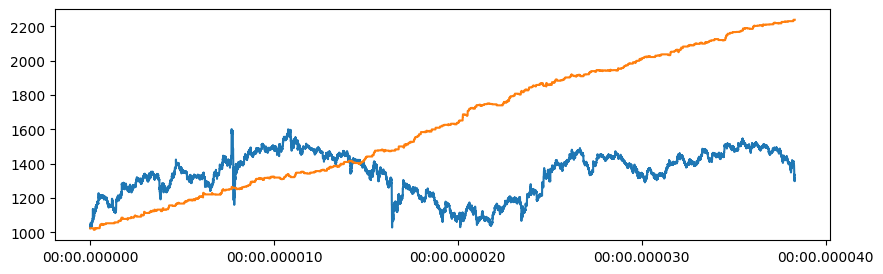

In [102]:
df["cumulative_pnl"] = df["trade_pnl_total"].cumsum()
df["equity_curve"] = starting_capital + df["cumulative_pnl"]

fig, ax = plt.subplots(figsize=(10,3))
ax.plot(df["close"])
ax.plot(df["equity_curve"])

In [103]:
def calculate_combined_metrics(df, starting_capital, trade_pnls, trade_pnls_short):
    """
    Calculate performance metrics for combined long/short strategy
    """
    import numpy as np
    
    # Combine trade PnLs
    trade_pnls_combined = trade_pnls + trade_pnls_short
    
    # Calculate returns based on combined trades
    returns_long = df[df['trade_pnl'] != 0]['trade_pnl'] / starting_capital
    returns_short = df[df['trade_pnl_short'] != 0]['trade_pnl_short'] / starting_capital
    returns_combined = pd.concat([returns_long, returns_short]).sort_index()
    
    # Daily equity-based Sharpe (correct for intraday)
    daily_equity = df.groupby(df.index.date)['equity_curve'].last()
    daily_returns = daily_equity.pct_change().dropna()
    sharpe = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252) if len(daily_returns) > 0 else 0
    
    # Total return
    total_return = (df['equity_curve'].iloc[-1] - starting_capital) / starting_capital * 100
    
    # Trade statistics
    num_trades_long = len(trade_pnls)
    num_trades_short = len(trade_pnls_short)
    num_trades_total = num_trades_long + num_trades_short
    
    # Win rates
    win_rate_long = (returns_long > 0).sum() / num_trades_long * 100 if num_trades_long > 0 else 0
    win_rate_short = (returns_short > 0).sum() / num_trades_short * 100 if num_trades_short > 0 else 0
    win_rate_combined = len([x for x in trade_pnls_combined if x > 0]) / num_trades_total * 100 if num_trades_total > 0 else 0
    
    # Max Drawdown
    running_max = df['equity_curve'].cummax()
    drawdown = (df['equity_curve'] - running_max) / running_max * 100
    max_drawdown = drawdown.min()
    
    # Profit Factor - Combined
    gross_profit_long = sum([x for x in trade_pnls if x > 0])
    gross_loss_long = abs(sum([x for x in trade_pnls if x < 0]))
    
    gross_profit_short = sum([x for x in trade_pnls_short if x > 0])
    gross_loss_short = abs(sum([x for x in trade_pnls_short if x < 0]))
    
    gross_profit_total = gross_profit_long + gross_profit_short
    gross_loss_total = gross_loss_long + gross_loss_short
    
    profit_factor_long = gross_profit_long / gross_loss_long if gross_loss_long > 0 else np.inf
    profit_factor_short = gross_profit_short / gross_loss_short if gross_loss_short > 0 else np.inf
    profit_factor_combined = gross_profit_total / gross_loss_total if gross_loss_total > 0 else np.inf
    
    # Average trade metrics
    avg_win_long = np.mean([x for x in trade_pnls if x > 0]) if len([x for x in trade_pnls if x > 0]) > 0 else 0
    avg_loss_long = np.mean([x for x in trade_pnls if x < 0]) if len([x for x in trade_pnls if x < 0]) > 0 else 0
    
    avg_win_short = np.mean([x for x in trade_pnls_short if x > 0]) if len([x for x in trade_pnls_short if x > 0]) > 0 else 0
    avg_loss_short = np.mean([x for x in trade_pnls_short if x < 0]) if len([x for x in trade_pnls_short if x < 0]) > 0 else 0
    
    avg_win_combined = np.mean([x for x in trade_pnls_combined if x > 0]) if len([x for x in trade_pnls_combined if x > 0]) > 0 else 0
    avg_loss_combined = np.mean([x for x in trade_pnls_combined if x < 0]) if len([x for x in trade_pnls_combined if x < 0]) > 0 else 0
    
    # Expectancy
    expectancy_combined = (win_rate_combined/100 * avg_win_combined) + ((1 - win_rate_combined/100) * avg_loss_combined)
    
    # Holding period analysis
    avg_holding_long = df[df['holding_period'].notna()]['holding_period'].mean() if 'holding_period' in df.columns else 0
    avg_holding_short = df[df['holding_period_short'].notna()]['holding_period_short'].mean() if 'holding_period_short' in df.columns else 0
    
    # Print results
    print("="*60)
    print("COMBINED STRATEGY PERFORMANCE")
    print("="*60)
    print(f"\n📊 OVERALL METRICS:")
    print(f"  Total Return: {total_return:.2f}%")
    print(f"  Sharpe Ratio: {sharpe:.2f}")
    print(f"  Max Drawdown: {max_drawdown:.2f}%")
    print(f"  Profit Factor: {profit_factor_combined:.2f}")
    print(f"  Expectancy per Trade: ₹{expectancy_combined:.2f}")
    
    print(f"\n📈 LONG TRADES:")
    print(f"  Total Trades: {num_trades_long}")
    print(f"  Win Rate: {win_rate_long:.2f}%")
    print(f"  Profit Factor: {profit_factor_long:.2f}")
    print(f"  Avg Win: ₹{avg_win_long:.2f} | Avg Loss: ₹{avg_loss_long:.2f}")
    print(f"  Avg Holding Period: {avg_holding_long:.1f} bars")
    
    print(f"\n📉 SHORT TRADES:")
    print(f"  Total Trades: {num_trades_short}")
    print(f"  Win Rate: {win_rate_short:.2f}%")
    print(f"  Profit Factor: {profit_factor_short:.2f}")
    print(f"  Avg Win: ₹{avg_win_short:.2f} | Avg Loss: ₹{avg_loss_short:.2f}")
    print(f"  Avg Holding Period: {avg_holding_short:.1f} bars")
    
    print(f"\n🎯 COMBINED TRADES:")
    print(f"  Total Trades: {num_trades_total}")
    print(f"  Win Rate: {win_rate_combined:.2f}%")
    print(f"  Avg Win: ₹{avg_win_combined:.2f} | Avg Loss: ₹{avg_loss_combined:.2f}")
    
    print("="*60)
    
    # Return metrics as dictionary for further analysis
    return {
        'total_return': total_return,
        'sharpe': sharpe,
        'max_drawdown': max_drawdown,
        'profit_factor': profit_factor_combined,
        'win_rate': win_rate_combined,
        'num_trades': num_trades_total,
        'expectancy': expectancy_combined,
        'long_stats': {
            'trades': num_trades_long,
            'win_rate': win_rate_long,
            'profit_factor': profit_factor_long
        },
        'short_stats': {
            'trades': num_trades_short,
            'win_rate': win_rate_short,
            'profit_factor': profit_factor_short
        }
    }

# Usage:
metrics = calculate_combined_metrics(df, starting_capital, trade_pnls, trade_pnls_short)

COMBINED STRATEGY PERFORMANCE

📊 OVERALL METRICS:
  Total Return: 118.57%
  Sharpe Ratio: 0.00
  Max Drawdown: -1.35%
  Profit Factor: 2.77
  Expectancy per Trade: ₹2.00

📈 LONG TRADES:
  Total Trades: 275
  Win Rate: 64.73%
  Profit Factor: 2.25
  Avg Win: ₹4.66 | Avg Loss: ₹-3.80
  Avg Holding Period: 5.7 bars

📉 SHORT TRADES:
  Total Trades: 331
  Win Rate: 75.23%
  Profit Factor: 3.39
  Avg Win: ₹4.30 | Avg Loss: ₹-3.85
  Avg Holding Period: 5.0 bars

🎯 COMBINED TRADES:
  Total Trades: 606
  Win Rate: 70.46%
  Avg Win: ₹4.45 | Avg Loss: ₹-3.82


In [104]:
required_columns = ['open', 'high', 'low', 'close', 'volume', 'resistance', 'support','atr', 'rsi', 'sma_50', 'sma_200', 'sma_20','uptrend','ml_target', 'ml_target_short']
df = df[required_columns]
df.head()

,open,high,low,close,volume,resistance,support,atr,rsi,sma_50,sma_200,sma_20,uptrend,ml_target,ml_target_short
1970-01-01 00:00:00.000000010,1024.20,1025.00,1024.05,1024.20,10278,1027.75,1024.05,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
1970-01-01 00:00:00.000000011,1024.20,1024.65,1023.10,1023.60,13020,1027.75,1024.05,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
1970-01-01 00:00:00.000000012,1023.60,1024.95,1023.50,1023.75,14442,1026.70,1023.60,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
1970-01-01 00:00:00.000000013,1023.75,1025.00,1023.10,1024.85,11583,1026.70,1023.60,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
1970-01-01 00:00:00.000000014,1024.35,1025.80,1024.35,1025.00,8428,1025.50,1023.60,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN


In [105]:
# required_columns = ['open', 'high', 'low', 'close', 'volume', 'resistance', 'support','atr', 'rsi', 'sma_50', 'sma_200', 'sma_20','uptrend','downtrend']
# df = df[required_columns]
# df.head()

In [106]:
# df.to_csv(f"./machine_learning_data/{filename}.csv", index='datetime')